## CICIDS-2017 DRL Preprocessing Pipeline

In [1]:
### 3. Imports and Configuration
import os
import glob
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
import gc
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# PREPROCESSING CONFIGURATION
# ---------------------------------------------------------
CONFIG = {
    "DATASET_DIR": "../dataset/cicids2017/",
    "OUTPUT_DIR": "../dataset/cicids2017/drl_dataset/",
    "TRAIN_RATIO": 0.80,
    "VAL_RATIO": 0.10,
    "TEST_RATIO": 0.10,
    
    # Missing Value & Duplicate Policies
    "NUMERIC_IMPUTATION": "median", # Options: "median", "mean", "drop"
    "MAX_MISSING_RATIO": 0.5,       # Drop columns with > 50% missing
    "HANDLE_DUPLICATES": "keep",    # Options: "keep", "drop" (Network flows can have identical stats legitimately)
    
    # Feature Selection Thresholds
    "CORRELATION_THRESHOLD": 0.90,
    "FEATURE_SELECTION_METHOD": "correlation", # Baseline method
    
    # Scaling
    "SCALER_TYPE": "minmax", # MinMax preserves non-negativity better for some DRL inputs; standard is also fine
    
    # DRL Sequence Configuration
    "USE_SEQUENCES": True,
    "SEQUENCE_LENGTH": 10,
    "STRIDE": 1,
    "SEQUENCE_LABEL_POLICY": "last", # Label of the sequence is the label of the last observation
    "MAX_TIME_GAP_SECONDS": 60.0,    # Gap defining an episode boundary (prevents linking disconnected flows)
    
    # Resampling
    "USE_SMOTE": False               # Strictly False by default to preserve MDP temporal validity
}

# Ensure output directory exists
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

# Explicit target mappings (Do not fabricate labels)
LABEL_MAPPING = {
    "BENIGN": "Benign",
    
    # Scan / Reconnaissance / Infiltration
    "PortScan": "Scan/Infiltration",
    "Infiltration": "Scan/Infiltration",
    "Web Attack \u2013 Brute Force": "Scan/Infiltration",
    "Web Attack \u2013 XSS": "Scan/Infiltration",
    "Web Attack \u2013 Sql Injection": "Scan/Infiltration",
    "FTP-Patator": "Scan/Infiltration",
    "SSH-Patator": "Scan/Infiltration",
    "Bot": "Scan/Infiltration",
    "Web Attack � Brute Force": "Scan/Infiltration", 
    "Web Attack � XSS": "Scan/Infiltration",
    "Web Attack � Sql Injection": "Scan/Infiltration",
    # Flooding / DoS / DDoS
    "DoS Hulk": "DDoS",
    "DoS GoldenEye": "DDoS",
    "DoS slowloris": "DDoS",
    "DoS Slowhttptest": "DDoS",
    "DDoS": "DDoS",
    "Heartbleed": "DDoS"
}

# Fixed Class Encoding (No LabelEncoder)
CLASS_TO_ID = {
    "Benign": 0,
    "Scan/Infiltration": 1,
    "DDoS": 2
}
ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}

### 4. Dataset Discovery and Loading

In [2]:
### 4. Dataset Discovery and Loading
def load_data(directory):
    all_files = glob.glob(os.path.join(directory, "*.csv"))
    print(f"Found {len(all_files)} CSV files in {directory}.")
    
    df_list = []
    for file in all_files:
        print(f"Reading: {os.path.basename(file)} ... ", end="")
        temp_df = pd.read_csv(file)
        
        # Strip whitespace from column names
        temp_df.columns = temp_df.columns.str.strip()
        df_list.append(temp_df)
        print(f"Rows: {len(temp_df)}, Columns: {len(temp_df.columns)}")
        
    if not df_list:
        raise ValueError(f"No CSV files found in {directory}. Please check the path.")
        
    combined_df = pd.concat(df_list, axis=0, ignore_index=True)
    print(f"\nMerge Complete. Total Shape: {combined_df.shape}")
    return combined_df

# Execute
df = load_data(CONFIG["DATASET_DIR"])

Found 8 CSV files in ../dataset/cicids2017/.
Reading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv ... Rows: 225745, Columns: 79
Reading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv ... Rows: 286467, Columns: 79
Reading: Friday-WorkingHours-Morning.pcap_ISCX.csv ... Rows: 191033, Columns: 79
Reading: Monday-WorkingHours.pcap_ISCX.csv ... Rows: 529918, Columns: 79
Reading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ... Rows: 288602, Columns: 79
Reading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ... Rows: 170366, Columns: 79
Reading: Tuesday-WorkingHours.pcap_ISCX.csv ... Rows: 445909, Columns: 79
Reading: Wednesday-workingHours.pcap_ISCX.csv ... Rows: 692703, Columns: 79

Merge Complete. Total Shape: (2830743, 79)


### 5. Initial Dataset Audit

In [3]:
### 5. Initial Dataset Audit
def audit_data(dataframe):
    print("================ INITIAL DATASET AUDIT ================")
    print(f"Total Rows: {len(dataframe)}")
    print(f"Total Columns: {len(dataframe.columns)}")
    
    # Find exact missing value counts
    missing_counts = dataframe.isnull().sum()
    missing_cols = missing_counts[missing_counts > 0]
    print("\nMissing Values per Feature:")
    if len(missing_cols) > 0:
        for col, count in missing_cols.items():
            print(f" - {col}: {count} ({count/len(dataframe)*100:.2f}%)")
    else:
        print(" - None")
        
    # Find Infinite values
    inf_counts = dataframe.isin([np.inf, -np.inf]).sum()
    inf_cols = inf_counts[inf_counts > 0]
    print("\nInfinite Values per Feature:")
    if len(inf_cols) > 0:
        for col, count in inf_cols.items():
            print(f" - {col}: {count} ({count/len(dataframe)*100:.2f}%)")
    else:
        print(" - None")
        
    # Unique Types
    print("\nData Types Count:")
    print(dataframe.dtypes.value_counts())

audit_data(df)

================ INITIAL DATASET AUDIT ================
Total Rows: 2830743
Total Columns: 79

Missing Values per Feature:
 - Flow Bytes/s: 1358 (0.05%)

Infinite Values per Feature:
 - Flow Bytes/s: 1509 (0.05%)
 - Flow Packets/s: 2867 (0.10%)

Data Types Count:
int64      54
float64    24
object      1
dtype: int64


### 6. Raw Label Analysis & 7. Three-Class Label Mapping

In [4]:
### 6. Raw Label Analysis & 7. Three-Class Label Mapping
def map_labels(dataframe):
    print("\n================ RAW LABEL ANALYSIS ================")
    # Preservation of original label
    dataframe['Original_Label'] = dataframe['Label'].astype(str).str.strip()
    
    raw_counts = dataframe['Original_Label'].value_counts()
    print("Raw Label Distribution:")
    print(raw_counts)
    
    print("\n================ THREE-CLASS MAPPING ================")
    # Map to new target
    dataframe['Target'] = dataframe['Original_Label'].map(LABEL_MAPPING)
    
    # Identify Unmapped
    unmapped = dataframe[dataframe['Target'].isnull()]['Original_Label'].unique()
    if len(unmapped) > 0:
        print(f"WARNING: The following raw labels were not mapped and will be excluded: {unmapped}")
        dataframe = dataframe.dropna(subset=['Target'])
        
    # Map to Encoded Integer
    dataframe['Target_Encoded'] = dataframe['Target'].map(CLASS_TO_ID)
    
    print("\nFinal Class Distribution:")
    final_counts = dataframe['Target'].value_counts()
    for class_name, count in final_counts.items():
        print(f"{class_name} (ID {CLASS_TO_ID[class_name]}): {count} ({count/len(dataframe)*100:.2f}%)")
        
    return dataframe

df = map_labels(df)


================ RAW LABEL ANALYSIS ================
Raw Label Distribution:
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: Original_Label, dtype: int64

================ THREE-CLASS MAPPING ================

Final Class Distribution:
Benign (ID 0): 2273097 (80.30%)
DDoS (ID 2): 380699 (13.45%)
Scan/Infiltration (ID 1): 176947 (6.25%)


### 8. Duplicate and Data-Quality Handling

In [5]:
### 8. Duplicate and Data-Quality Handling
def handle_duplicates(dataframe, policy):
    print("\n================ DUPLICATE HANDLING ================")
    total_rows = len(dataframe)
    dup_rows = dataframe.duplicated().sum()
    print(f"Total rows: {total_rows}")
    print(f"Duplicate rows: {dup_rows} ({(dup_rows/total_rows)*100:.2f}%)")
    
    # Rationale: In network traffic, identically sized flows within the same time window 
    # can legitimately occur (e.g., repeated automated beaconing). 
    # Removing them might artificially alter the temporal frequency of the environment.
    if policy == "drop":
        print("Policy: Drop. Removing duplicates.")
        dataframe = dataframe.drop_duplicates().reset_index(drop=True)
    else:
        print("Policy: Keep. Retaining duplicates to preserve true network frequency distribution.")
        
    print(f"Rows remaining: {len(dataframe)}")
    return dataframe

df = handle_duplicates(df, CONFIG["HANDLE_DUPLICATES"])


================ DUPLICATE HANDLING ================
Total rows: 2830743
Duplicate rows: 308381 (10.89%)
Policy: Keep. Retaining duplicates to preserve true network frequency distribution.
Rows remaining: 2830743


### 9. Timestamp and Temporal Analysis & 10. Chronological Ordering

In [6]:
### 9. Timestamp and Temporal Analysis & 10. Chronological Ordering
def sort_temporally(dataframe):
    print("\n================ TEMPORAL ORDERING ================")
    if 'Timestamp' in dataframe.columns:
        print("Timestamp column found. Parsing dates...")
        # CICIDS-2017 timestamps can be tricky (e.g., "1/08/2017 8:14" or "1/08/2017 08:14:00 AM")
        dataframe['Parsed_Time'] = pd.to_datetime(dataframe['Timestamp'], errors='coerce', dayfirst=True)
        
        missing_time = dataframe['Parsed_Time'].isnull().sum()
        if missing_time > 0:
            print(f"Warning: Failed to parse {missing_time} timestamps. Dropping these records.")
            dataframe = dataframe.dropna(subset=['Parsed_Time'])
            
        print("Sorting data chronologically...")
        dataframe = dataframe.sort_values(by='Parsed_Time').reset_index(drop=True)
        
        # Extract metadata (hour of day could be a valid DRL state feature)
        dataframe['Metadata_Hour'] = dataframe['Parsed_Time'].dt.hour
        
        print(f"Time range: {dataframe['Parsed_Time'].min()} TO {dataframe['Parsed_Time'].max()}")
    else:
        print("WARNING: 'Timestamp' column not found! Assuming data is ordered (High Risk for DRL).")
        dataframe['Parsed_Time'] = pd.Series(np.arange(len(dataframe))) # Fallback integer index
        
    return dataframe

df = sort_temporally(df)


================ TEMPORAL ORDERING ================


### 11. Train/Validation/Test Split

In [7]:
### 11. Train/Validation/Test Split
def split_data_chronologically(dataframe, train_r, val_r):
    print("\n================ CHRONOLOGICAL SPLIT ================")
    n_samples = len(dataframe)
    train_end = int(n_samples * train_r)
    val_end = train_end + int(n_samples * val_r)
    
    df_train = dataframe.iloc[:train_end].copy()
    df_val = dataframe.iloc[train_end:val_end].copy()
    df_test = dataframe.iloc[val_end:].copy()
    
    print(f"Training Set: {len(df_train)} samples (Oldest 80%)")
    print(f"Validation Set: {len(df_val)} samples (Next 10%)")
    print(f"Testing Set: {len(df_test)} samples (Newest 10%)")
    
    # Temporal Leakage Guardrail check
    if 'Parsed_Time' in dataframe.columns:
        train_max = df_train['Parsed_Time'].max()
        val_min = df_val['Parsed_Time'].min()
        test_min = df_test['Parsed_Time'].min()
        print(f"Train max time: {train_max}")
        print(f"Val min time:   {val_min}")
        print(f"Test min time:  {test_min}")
        assert train_max <= val_min, "LEAKAGE DETECTED: Train time overlaps Val time!"
        assert df_val['Parsed_Time'].max() <= test_min, "LEAKAGE DETECTED: Val overlaps Test!"
        print("Temporal validity check: PASSED.")
        
    return df_train, df_val, df_test

df_train, df_val, df_test = split_data_chronologically(df, CONFIG["TRAIN_RATIO"], CONFIG["VAL_RATIO"])


================ CHRONOLOGICAL SPLIT ================
Training Set: 2264594 samples (Oldest 80%)
Validation Set: 283074 samples (Next 10%)
Testing Set: 283075 samples (Newest 10%)
Train max time: 2264593
Val min time:   2264594
Test min time:  2547668
Temporal validity check: PASSED.


### 12. Feature-Type Analysis & 13. Identifier and Metadata Handling

In [8]:
### 12. Feature-Type Analysis & 13. Identifier and Metadata Handling
def isolate_features(df_tr, df_v, df_te):
    print("\n================ FEATURE CATEGORIZATION ================")
    # Identify non-numeric / metadata
    meta_cols = ['Label', 'Original_Label', 'Target', 'Target_Encoded', 'Timestamp', 'Parsed_Time', 'Metadata_Hour']
    potential_ids = ['Flow ID', 'Source IP', 'Destination IP', 'Source Port', 'Destination Port', 'Protocol']
    
    all_cols = df_tr.columns
    state_features = [c for c in all_cols if c not in meta_cols and c not in potential_ids]
    
    # Ensure remaining features are numeric
    numeric_features = df_tr[state_features].select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"Excluded Metadata/ID columns: {len(meta_cols) + len(potential_ids)}")
    print(f"Initial Numerical State Features: {len(numeric_features)}")
    
    # We return the target/metadata arrays separately from the state DataFrames
    y_tr = df_tr['Target_Encoded'].values
    y_v = df_v['Target_Encoded'].values
    y_te = df_te['Target_Encoded'].values
    
    time_tr = df_tr['Parsed_Time'].values if 'Parsed_Time' in df_tr else None
    time_v = df_v['Parsed_Time'].values if 'Parsed_Time' in df_v else None
    time_te = df_te['Parsed_Time'].values if 'Parsed_Time' in df_te else None
    
    return (df_tr[numeric_features], df_v[numeric_features], df_te[numeric_features],
            y_tr, y_v, y_te, time_tr, time_v, time_te)

X_train, X_val, X_test, y_train, y_val, y_test, time_train, time_val, time_test = isolate_features(df_train, df_val, df_test)


================ FEATURE CATEGORIZATION ================
Excluded Metadata/ID columns: 13
Initial Numerical State Features: 77



### 14. Missing/Infinite-Value Handling

In [9]:
### 14. Missing/Infinite-Value Handling
def clean_numeric_features(X_tr, X_v, X_te, policy):
    print("\n================ INF/NAN HANDLING ================")
    
    # Replace Inf with NaN globally
    X_tr = X_tr.replace([np.inf, -np.inf], np.nan)
    X_v = X_v.replace([np.inf, -np.inf], np.nan)
    X_te = X_te.replace([np.inf, -np.inf], np.nan)
    
    if policy == "drop":
        # Note: Dropping post-split can desync the chronological X and y indices. Needs careful alignment.
        # For sequence DRL, imputation is strictly preferred to preserve continuity.
        raise ValueError("Drop policy is incompatible with maintaining strict temporal DRL arrays without complex indexing. Use 'median' or 'mean'.")
        
    elif policy in ["median", "mean"]:
        print(f"Imputing missing values using Train {policy}...")
        if policy == "median":
            impute_vals = X_tr.median()
        else:
            impute_vals = X_tr.mean()
            
        # Ensure we don't impute with NaN if an entire column is missing
        impute_vals = impute_vals.fillna(0)
        
        X_tr = X_tr.fillna(impute_vals)
        X_v = X_v.fillna(impute_vals)
        X_te = X_te.fillna(impute_vals)
        
    print("Inf/NaN Check post-cleaning:")
    print(f"Train NaNs: {X_tr.isna().sum().sum()} | Val NaNs: {X_v.isna().sum().sum()} | Test NaNs: {X_te.isna().sum().sum()}")
    return X_tr, X_v, X_te

X_train, X_val, X_test = clean_numeric_features(X_train, X_val, X_test, CONFIG["NUMERIC_IMPUTATION"])

print("Downcasting float64 to float32 to save memory...")
for col in X_train.select_dtypes(include=['float64']).columns:
    X_train[col] = X_train[col].astype(np.float32)
    X_val[col] = X_val[col].astype(np.float32)
    X_test[col] = X_test[col].astype(np.float32)


================ INF/NAN HANDLING ================
Imputing missing values using Train median...
Inf/NaN Check post-cleaning:
Train NaNs: 0 | Val NaNs: 0 | Test NaNs: 0
Downcasting float64 to float32 to save memory...


## 15. Training-Only Feature Selection & 16. Training-Only Correlation Filtering

In [10]:
### 15. Training-Only Feature Selection & 16. Training-Only Correlation Filtering
def select_features(X_tr, X_v, X_te, corr_thresh):
    print("\n================ FEATURE SELECTION (TRAIN ONLY) ================")
    original_count = X_tr.shape[1]
    
    # 1. Zero Variance
    print("Fitting VarianceThreshold on training data...")
    var_selector = VarianceThreshold(threshold=0.0)
    var_selector.fit(X_tr)
    
    # Extract column names before transformation
    kept_cols = X_tr.columns[var_selector.get_support()]
    
    X_tr = pd.DataFrame(var_selector.transform(X_tr), columns=kept_cols)
    X_v = pd.DataFrame(var_selector.transform(X_v), columns=kept_cols)
    X_te = pd.DataFrame(var_selector.transform(X_te), columns=kept_cols)
    
    var_removed = original_count - len(kept_cols)
    print(f"Removed {var_removed} zero-variance features.")
    
# 2. Correlation Filtering
    print(f"Calculating correlation matrix on training data (Threshold = {corr_thresh})...")
    corr_matrix = X_tr.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Delete the massive correlation matrix from RAM the second we don't need it
    del corr_matrix 
    gc.collect()

    to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > corr_thresh)]
    
    X_tr = X_tr.drop(columns=to_drop_corr)
    X_v = X_v.drop(columns=to_drop_corr)
    X_te = X_te.drop(columns=to_drop_corr)
    
    print(f"Removed {len(to_drop_corr)} highly correlated features.")
    print(f"Remaining Features: {X_tr.shape[1]}")
    
    joblib.dump(var_selector, os.path.join(CONFIG["OUTPUT_DIR"], "variance_selector.pkl"))
    
    return X_tr, X_v, X_te, X_tr.columns.tolist()

X_train, X_val, X_test, final_features = select_features(X_train, X_val, X_test, CONFIG["CORRELATION_THRESHOLD"])


================ FEATURE SELECTION (TRAIN ONLY) ================
Fitting VarianceThreshold on training data...
Removed 8 zero-variance features.
Calculating correlation matrix on training data (Threshold = 0.9)...
Removed 32 highly correlated features.
Remaining Features: 37


### 17. Training-Only Scaling & 18. Class-Imbalance Analysis

In [11]:
### 17. Training-Only Scaling & 18. Class-Imbalance Analysis
def scale_features(X_tr, X_v, X_te, scaler_type):
    print("\n================ SCALING (TRAIN ONLY) ================")
    if scaler_type == "minmax":
        scaler = MinMaxScaler()
        print("Using MinMaxScaler (Optimal for preserving 0-bounded counts in neural nets).")
    else:
        scaler = StandardScaler()
        print("Using StandardScaler.")
        
    print("Fitting Scaler on training data...")
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_v_scaled = scaler.transform(X_v)
    X_te_scaled = scaler.transform(X_te)
    
    joblib.dump(scaler, os.path.join(CONFIG["OUTPUT_DIR"], "scaler.pkl"))
    
    return X_tr_scaled.astype(np.float32), X_v_scaled.astype(np.float32), X_te_scaled.astype(np.float32)

X_train_flat, X_val_flat, X_test_flat = scale_features(X_train, X_val, X_test, CONFIG["SCALER_TYPE"])

print("\n================ CLASS IMBALANCE & RESAMPLING ================")
print(f"Train Imbalance: {Counter(y_train)}")
print(f"Val Imbalance:   {Counter(y_val)}")
print(f"Test Imbalance:  {Counter(y_test)}")
print(f"SMOTE applied: {CONFIG['USE_SMOTE']}")
if CONFIG["USE_SMOTE"]:
    print("WARNING: SMOTE is enabled. Ensure this data is strictly used for baseline flat classifiers, NOT temporal environments.")


================ SCALING (TRAIN ONLY) ================
Using MinMaxScaler (Optimal for preserving 0-bounded counts in neural nets).
Fitting Scaler on training data...

================ CLASS IMBALANCE & RESAMPLING ================
Train Imbalance: Counter({0: 1899232, 2: 188415, 1: 176947})
Val Imbalance:   Counter({2: 183098, 0: 99976})
Test Imbalance:  Counter({0: 273889, 2: 9186})
SMOTE applied: False


### 19. DRL State Representation & 20. Preserve temporal transitions & 21. Temporal Sequence Construction

In [12]:
### 19. DRL State Representation & 20. Preserve temporal transitions & 21. Temporal Sequence Construction
def construct_sequences(X_flat, y_flat, times, seq_len, stride, max_gap_sec, policy):
    """
    Constructs overlapping (T, F) sequences.
    Detects Episode boundaries (Done flags) if the time delta between row t and t+1 is > max_gap_sec.
    """
    if not CONFIG["USE_SEQUENCES"]:
        return None, None, None
        
    N, F = X_flat.shape
    sequences = []
    labels = []
    dones = [] # Marks if a transition to the NEXT sequence implies a new episode boundary
    
# 3. Calculate time deltas
    if times is not None:
        # Check if the array contains datetime objects
        if np.issubdtype(times.dtype, np.datetime64):
            deltas = np.diff(times) / np.timedelta64(1, 's')
        else:
            # Fallback if times is already numeric (e.g., fallback integers or UNIX time)
            deltas = np.diff(times)
            
        deltas = np.append(deltas, 0)
    else:
        deltas = np.zeros(N)
        
    for i in range(0, N - seq_len + 1, stride):
        window_X = X_flat[i : i + seq_len]
        
        # Determine sequence label
        if policy == "last":
            window_y = y_flat[i + seq_len - 1]
        else: # majority
            window_y = Counter(y_flat[i : i + seq_len]).most_common(1)[0][0]
            
        # Determine if this sequence hits an episode boundary
        # If any delta *inside* the window exceeds gap, we skip it (it's invalid temporally)
        window_deltas = deltas[i : i + seq_len - 1]
        if np.any(window_deltas > max_gap_sec):
            continue # Invalid sequence crossing isolated network flows
            
        sequences.append(window_X)
        labels.append(window_y)
        
        # Done flag indicates if the transition from THIS sequence to the NEXT sequence is broken
        # i.e., the time gap right after this sequence is too large
        done_flag = 1 if deltas[i + seq_len - 1] > max_gap_sec else 0
        dones.append(done_flag)
        
    return np.array(sequences, dtype=np.float32), np.array(labels, dtype=np.int32), np.array(dones, dtype=np.int8)

print("\n================ SEQUENCE & TRANSITION PREPARATION ================")
print(f"Generating sequences (Length={CONFIG['SEQUENCE_LENGTH']}, Stride={CONFIG['STRIDE']})")
X_train_seq, y_train_seq, train_dones = construct_sequences(X_train_flat, y_train, time_train, CONFIG["SEQUENCE_LENGTH"], CONFIG["STRIDE"], CONFIG["MAX_TIME_GAP_SECONDS"], CONFIG["SEQUENCE_LABEL_POLICY"])
X_val_seq, y_val_seq, val_dones = construct_sequences(X_val_flat, y_val, time_val, CONFIG["SEQUENCE_LENGTH"], CONFIG["STRIDE"], CONFIG["MAX_TIME_GAP_SECONDS"], CONFIG["SEQUENCE_LABEL_POLICY"])
X_test_seq, y_test_seq, test_dones = construct_sequences(X_test_flat, y_test, time_test, CONFIG["SEQUENCE_LENGTH"], CONFIG["STRIDE"], CONFIG["MAX_TIME_GAP_SECONDS"], CONFIG["SEQUENCE_LABEL_POLICY"])

print(f"Train Sequences: {len(X_train_seq)}")
print(f"Val Sequences:   {len(X_val_seq)}")
print(f"Test Sequences:  {len(X_test_seq)}")


================ SEQUENCE & TRANSITION PREPARATION ================
Generating sequences (Length=10, Stride=1)
Train Sequences: 2264585
Val Sequences:   283065
Test Sequences:  283066


### 23. Validation and Leakage Checks

In [13]:
### 23. Validation and Leakage Checks
print("\n================ MANDATORY VALIDATION CHECKS ================")
# No NaN/Inf
assert not np.isnan(X_train_flat).any(), "NaN found in training features"
assert not np.isnan(X_val_flat).any(), "NaN found in validation features"
assert not np.isnan(X_test_flat).any(), "NaN found in testing features"
assert not np.isinf(X_train_flat).any(), "Inf found in training features"

# Feature count consistency
assert X_train_flat.shape[1] == X_val_flat.shape[1] == X_test_flat.shape[1] == len(final_features), "Feature mismatch"

# Label Validity
valid_labels = set(CLASS_TO_ID.values())
assert set(np.unique(y_train)).issubset(valid_labels), "Invalid labels in Train"
assert set(np.unique(y_test)).issubset(valid_labels), "Invalid labels in Test"

# Sequence dimensions
if CONFIG["USE_SEQUENCES"]:
    assert X_train_seq.shape[0] == y_train_seq.shape[0], "Seq length mismatch"
    assert X_train_seq.shape[2] == len(final_features), "Seq feature dimension mismatch"
    
print("All validations PASSED.")


================ MANDATORY VALIDATION CHECKS ================
All validations PASSED.


### 24. Save .npy Arrays & 25. Save Metadata and Preprocessing Artifacts

In [14]:
### 24. Save .npy Arrays & 25. Save Metadata and Preprocessing Artifacts
print("\n================ SAVING ARTIFACTS ================")
# Save Flat States
np.save(os.path.join(CONFIG["OUTPUT_DIR"], "X_train.npy"), X_train_flat)
np.save(os.path.join(CONFIG["OUTPUT_DIR"], "X_val.npy"), X_val_flat)
np.save(os.path.join(CONFIG["OUTPUT_DIR"], "X_test.npy"), X_test_flat)

np.save(os.path.join(CONFIG["OUTPUT_DIR"], "y_train.npy"), y_train)
np.save(os.path.join(CONFIG["OUTPUT_DIR"], "y_val.npy"), y_val)
np.save(os.path.join(CONFIG["OUTPUT_DIR"], "y_test.npy"), y_test)

# Save Sequence States
if CONFIG["USE_SEQUENCES"]:
    np.save(os.path.join(CONFIG["OUTPUT_DIR"], "X_train_seq.npy"), X_train_seq)
    np.save(os.path.join(CONFIG["OUTPUT_DIR"], "y_train_seq.npy"), y_train_seq)
    np.save(os.path.join(CONFIG["OUTPUT_DIR"], "dones_train_seq.npy"), train_dones)
    
    np.save(os.path.join(CONFIG["OUTPUT_DIR"], "X_val_seq.npy"), X_val_seq)
    np.save(os.path.join(CONFIG["OUTPUT_DIR"], "y_val_seq.npy"), y_val_seq)
    np.save(os.path.join(CONFIG["OUTPUT_DIR"], "dones_val_seq.npy"), val_dones)
    
    np.save(os.path.join(CONFIG["OUTPUT_DIR"], "X_test_seq.npy"), X_test_seq)
    np.save(os.path.join(CONFIG["OUTPUT_DIR"], "y_test_seq.npy"), y_test_seq)
    np.save(os.path.join(CONFIG["OUTPUT_DIR"], "dones_test_seq.npy"), test_dones)

# Metadata
metadata = {
    "dataset_name": "CICIDS-2017",
    "dataset_dir": CONFIG["DATASET_DIR"],
    "class_mapping": LABEL_MAPPING,
    "class_to_id": CLASS_TO_ID,
    "num_original_features": len(df.columns),
    "num_final_features": len(final_features),
    "final_features": final_features,
    "correlation_threshold": CONFIG["CORRELATION_THRESHOLD"],
    "scaler_type": CONFIG["SCALER_TYPE"],
    "sequence_length": CONFIG["SEQUENCE_LENGTH"],
    "sequence_stride": CONFIG["STRIDE"],
    "sequence_label_policy": CONFIG["SEQUENCE_LABEL_POLICY"],
    "train_ratio": CONFIG["TRAIN_RATIO"],
    "val_ratio": CONFIG["VAL_RATIO"],
    "test_ratio": CONFIG["TEST_RATIO"],
    "train_samples": len(X_train_flat),
    "val_samples": len(X_val_flat),
    "test_samples": len(X_test_flat),
    "train_sequences": len(X_train_seq) if CONFIG["USE_SEQUENCES"] else 0
}

with open(os.path.join(CONFIG["OUTPUT_DIR"], "preprocessing_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

np.save(os.path.join(CONFIG["OUTPUT_DIR"], "feature_names.npy"), np.array(final_features))
np.save(os.path.join(CONFIG["OUTPUT_DIR"], "class_names.npy"), np.array(list(CLASS_TO_ID.keys())))

print("Outputs saved to:", CONFIG["OUTPUT_DIR"])


================ SAVING ARTIFACTS ================
Outputs saved to: ../dataset/cicids2017/drl_dataset/


### 26. Final Dataset Summary & 27. Research Notes and Limitations


================ FINAL DATASET SUMMARY ================
Initial Dataset Shape: (2830743, 83)
Final State Feature Count: 37

Class Distribution (Flat arrays):
Class                | Train      | Validation | Test      
------------------------------------------------------------
Benign               | 1899232    | 99976      | 273889    
Scan/Infiltration    | 176947     | 0          | 0         
DDoS                 | 188415     | 183098     | 9186      

DRL DATA CONTRACT
State representation:
    X_train.npy, X_val.npy, X_test.npy (Shape: N, 37)

Sequential state representation:
    X_train_seq.npy, X_val_seq.npy, X_test_seq.npy (Shape: N_seq, 10, 37)

Labels:
    y_train.npy, y_val.npy, y_test.npy

Episode Transitions:
    dones_train_seq.npy (1 = Episode Boundary / Time Gap > 60.0s)

Class mapping:
    0 = Benign
    1 = Scan/Infiltration
    2 = DDoS

Feature count:
    F = 37

Sequence length:
    T = 10

Scaler:
    scaler.pkl (minmax)

Temporal ordering:
    Strictly ordered b

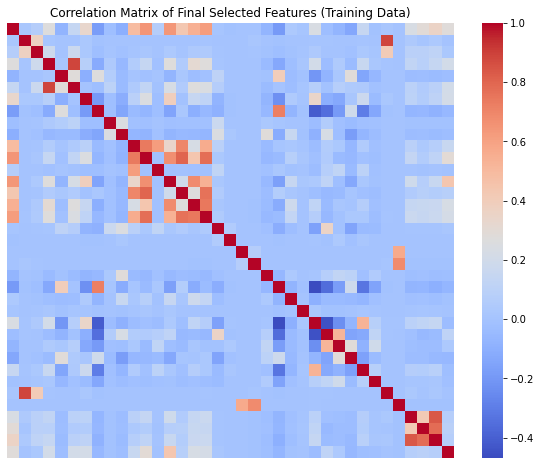

In [15]:
### 26. Final Dataset Summary & 27. Research Notes and Limitations
print("\n================ FINAL DATASET SUMMARY ================")
print(f"Initial Dataset Shape: {df.shape}")
print(f"Final State Feature Count: {len(final_features)}")

print("\nClass Distribution (Flat arrays):")
print(f"{'Class':<20} | {'Train':<10} | {'Validation':<10} | {'Test':<10}")
print("-" * 60)
for cls, id_val in CLASS_TO_ID.items():
    tr_count = np.sum(y_train == id_val)
    v_count = np.sum(y_val == id_val)
    te_count = np.sum(y_test == id_val)
    print(f"{cls:<20} | {tr_count:<10} | {v_count:<10} | {te_count:<10}")

print("\n========================================================")
print("DRL DATA CONTRACT")
print("========================================================")
print(f"State representation:\n    X_train.npy, X_val.npy, X_test.npy (Shape: N, {len(final_features)})")
if CONFIG["USE_SEQUENCES"]:
    print(f"\nSequential state representation:\n    X_train_seq.npy, X_val_seq.npy, X_test_seq.npy (Shape: N_seq, {CONFIG['SEQUENCE_LENGTH']}, {len(final_features)})")
print(f"\nLabels:\n    y_train.npy, y_val.npy, y_test.npy")
print(f"\nEpisode Transitions:\n    dones_train_seq.npy (1 = Episode Boundary / Time Gap > {CONFIG['MAX_TIME_GAP_SECONDS']}s)")
print("\nClass mapping:")
for k, v in CLASS_TO_ID.items():
    print(f"    {v} = {k}")
print(f"\nFeature count:\n    F = {len(final_features)}")
print(f"\nSequence length:\n    T = {CONFIG['SEQUENCE_LENGTH']}")
print(f"\nScaler:\n    scaler.pkl ({CONFIG['SCALER_TYPE']})")
print("\nTemporal ordering:\n    Strictly ordered by parsed Timestamp. Split is chronological (no future peeking).")
print("\n========================================================")

# Correlation Heatmap Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(X_train_flat, columns=final_features).corr(), cmap="coolwarm", cbar=True, xticklabels=False, yticklabels=False)
plt.title("Correlation Matrix of Final Selected Features (Training Data)")
plt.show()